# Loading Dependencies

In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models,callbacks,optimizers
import numpy as np
import random, os, glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Seet function for fix results
SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Data Collection

In [3]:
#loading the dataset
dataset_dir="/Users/datascientist/Downloads/MY_FYP/umaid_fyp/Rice_Leaf_AUG (1)"

In [4]:
class_names=[cls for cls in sorted(os.listdir(dataset_dir)) if not cls.startswith(".")]
print("Classes:",class_names)
all_images,all_labels=[],[]
for idx, cls in enumerate(class_names):
    files=glob.glob(os.path.join(dataset_dir,cls,"*.jpg"))+\
    glob.glob(os.path.join(dataset_dir,cls,"*.png"))  
    all_images.extend(files)
    all_labels.extend([idx]*len(files))
all_images=np.array(all_images)
all_labels=np.array(all_labels)

Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']


# Spliting the dataset 

### splitted dataset into 80-20% ratio , 80% for training and remaininig for validation

In [5]:
#Load dataset in an easy way
train_ds=tf.keras.utils.image_dataset_from_directory(dataset_dir,validation_split=0.2,subset="training",seed=SEED,image_size=(128,128),batch_size=32)
val_ds=tf.keras.utils.image_dataset_from_directory(dataset_dir,validation_split=0.2,subset="validation",seed=SEED,image_size=(128,128),batch_size=32)


# Class names from folder names
class_names=train_ds.class_names
print("Classes:",class_names)


Found 3829 files belonging to 6 classes.
Using 3064 files for training.
Using 3064 files for training.
Found 3829 files belonging to 6 classes.
Using 765 files for validation.
Found 3829 files belonging to 6 classes.
Using 765 files for validation.
Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']
Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']


# Data Preprocessing

In [6]:
#Normalize images into 0,1 range
normalization=tf.keras.layers.Rescaling(1./255)
train_ds=train_ds.map(lambda x,y:(normalization(x),y))
val_ds=val_ds.map(lambda x,y:(normalization(x),y))

#Improving performance by prefetching
train_ds=train_ds.prefetch(tf.data.AUTOTUNE)
val_ds=val_ds.prefetch(tf.data.AUTOTUNE)

# CNN MODEL

# Data Augmentation
Data augmentation helps improve model accuracy by creating variations of training images

In [ ]:
# Data Augmentation Layer
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# CNN model with data augmentation - Updated to avoid InputLayer compatibility issues
model=models.Sequential([
    # Data augmentation (only applied during training)
    data_augmentation,
    
    # Convolutional layers with BatchNormalization for better training
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256,(3,3),activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Dense layers
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6,activation='softmax')])  # 6 classes

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# setting the callbacks to save the best model, early stopping, and learning rate reduction
callback=[
    callbacks.EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True),
    callbacks.ModelCheckpoint("models/cnn_best_model.h5",save_best_only=True,monitor="val_loss"),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)]

In [ ]:
# train the model over 50 epochs (with early stopping)
history=model.fit(train_ds,validation_data=val_ds,epochs=50,callbacks=callback)

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.2786 - loss: 1.6947

96/96 ━━━━━━━━━━━━━━━━━━━━ 90s 920ms/step - accuracy: 0.3476 - loss: 1.5817 - val_accuracy: 0.5007 - val_loss: 1.2676
Epoch 2/30
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.4680 - loss: 1.3404

96/96 ━━━━━━━━━━━━━━━━━━━━ 67s 691ms/step - accuracy: 0.4902 - loss: 1.2754 - val_accuracy: 0.5216 - val_loss: 1.2063
Epoch 3/30
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.5723 - loss: 1.1194

96/96 ━━━━━━━━━━━━━━━━━━━━ 59s 610ms/step - accuracy: 0.5773 - loss: 1.0956 - val_accuracy: 0.6209 - val_loss: 0.9654
Epoch 4/30
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.6524 - loss: 0.9521

96/96 ━━━━━━━━━━━━━━━━━━━━ 59s 611ms/step - accuracy: 0.6403 - loss: 0.9575 - val_accuracy: 0.6614 - val_loss: 0.8897
Epoch 5/30
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.6672 - loss: 0.8679

96/96 ━━━━━━━━━━━━━━━━━━━━ 51s 530ms/step - accuracy: 0.6860 - loss: 0.8308 - val_accuracy: 0.7046 - val_loss: 0.8223
Epoch 6/30
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.7055 - loss: 0.8036

96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 587ms/step - accuracy: 0.7134 - loss: 0.7704 - val_accuracy: 0.7190 - val_loss: 0.7614
Epoch 7/30
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 576ms/step - accuracy: 0.7461 - loss: 0.6907 - val_accuracy: 0.7281 - val_loss: 0.7663
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 576ms/step - accuracy: 0.7461 - loss: 0.6907 - val_accuracy: 0.7281 - val_loss: 0.7663
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 569ms/step - accuracy: 0.7836 - loss: 0.5916 - val_accuracy: 0.7098 - val_loss: 0.8114
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 569ms/step - accuracy: 0.7836 - loss: 0.5916 - val_accuracy: 0.7098 - val_loss: 0.8114
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 52s 540ms/step - accuracy: 0.7732 - loss: 0.6056 - val_accuracy: 0.7216 - val_loss: 0.8231
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 52s 540ms/step - accuracy: 0.7732 - loss: 0.6056 - val_accuracy: 0.7216 - val_loss: 0.8231
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.8007 - loss: 0.5259

96/96 ━━━━━━━━━━━━━━━━━━━━ 57s 591ms/step - accuracy: 0.8022 - loss: 0.5156 - val_accuracy: 0.7307 - val_loss: 0.7503
Epoch 11/30
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 62s 644ms/step - accuracy: 0.8401 - loss: 0.4297 - val_accuracy: 0.7216 - val_loss: 0.8439
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 62s 644ms/step - accuracy: 0.8401 - loss: 0.4297 - val_accuracy: 0.7216 - val_loss: 0.8439
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 60s 624ms/step - accuracy: 0.8528 - loss: 0.4001 - val_accuracy: 0.7569 - val_loss: 0.7738
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 60s 624ms/step - accuracy: 0.8528 - loss: 0.4001 - val_accuracy: 0.7569 - val_loss: 0.7738
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 570ms/step - accuracy: 0.8633 - loss: 0.3505 - val_accuracy: 0.7699 - val_loss: 0.7561
Epoch 14/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 55s 570ms/step - accuracy: 0.8633 - loss: 0.3505 - val_accuracy: 0.7699 - val_loss: 0.7561
Epoch 14/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 767ms/step - accuracy: 0.8796 - loss: 0.3078 - 

# Evaluate the model

In [10]:
loss,acc=model.evaluate(val_ds)
print(f"\nFinal Validation Accuracy:{acc*100:.2f}%")

24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 388ms/step - accuracy: 0.7307 - loss: 0.7503
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 388ms/step - accuracy: 0.7307 - loss: 0.7503

Final Validation Accuracy:73.07%

Final Validation Accuracy:73.07%


# Graphical representation of model performance

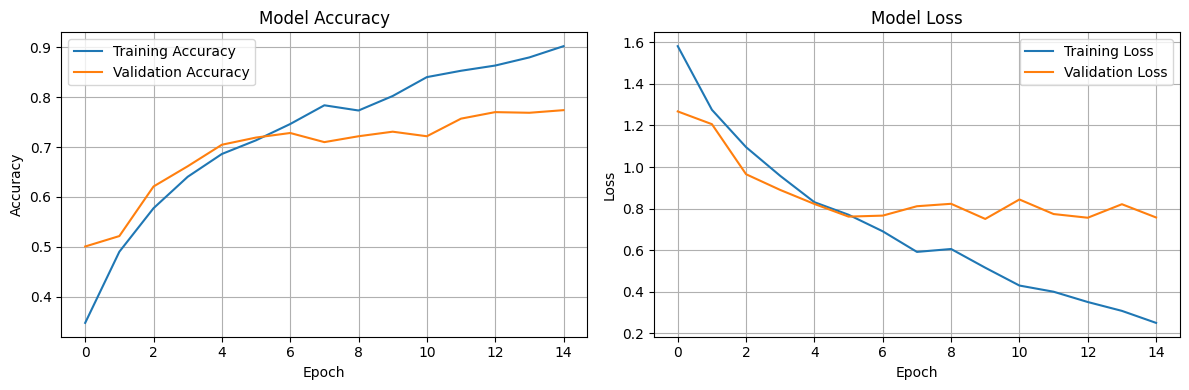

In [11]:
plt.figure(figsize=(12,4))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('models/training_history.png')
plt.show()


# Prediction function for testing the images of plant

In [12]:
# def predict_leaf(img_path,model_path="/Users/datascientist/Downloads/MY_FYP/Project/models/cnn_best_model.h5"):
#     model=tf.keras.models.load_model(model_path)
#     img=image.load_img(img_path,target_size=(128,128))
#     img_array=image.img_to_array(img)/255.0
#     img_array=np.expand_dims(img_array,axis=0)

#     predictions=model.predict(img_array)
#     predicted_class=class_names[np.argmax(predictions)]
#     confidence=np.max(predictions)*100
#     print(f"Predicted Disease: {predicted_class} ({confidence:.2f}%)")
#     return predicted_class,confidence

# predict_leaf('/Users/datascientist/Downloads/MY_FYP/Project/dataset/rice leaf dataset/Bacterialblight/BACTERAILBLIGHT4_024.jpg')

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import cv2
import os

# Load trained model
model=tf.keras.models.load_model("models/cnn_best_model.h5")
class_names=['Bacterial Leaf Blight','Brown Spot','Healthy Rice Leaf','Leaf Blast','Leaf scald','Sheath Blight']

def predict_leaf(img_path):
    img=image.load_img(img_path,target_size=(128,128))
    img_array=image.img_to_array(img) / 255.0
    img_array=np.expand_dims(img_array,axis=0)

    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions)]
    confidence=np.max(predictions) * 100
    return predicted_class,confidence

#image pathh
file_path="/Users/datascientist/Downloads/MY_FYP/umaid_fyp/Rice_Leaf_AUG (1)/Healthy Rice Leaf/20231006_163255.jpg"

if os.path.exists(file_path):
    predicted_class,confidence=predict_leaf(file_path)
    print(f"Predicted Disease: {predicted_class} ({confidence:.2f}%)")

    img=cv2.imread(file_path)
    screen_w, screen_h=1000, 700
    h,w=img.shape[:2]
    if w > screen_w or h > screen_h:
        scale=min(screen_w / w, screen_h / h)
        img=cv2.resize(img, (int(w * scale),int(h * scale)))
    cv2.putText(img, f"{predicted_class} ({confidence:.2f}%)",
                (10, 40), cv2.FONT_HERSHEY_SIMPLEX,
                1, (0, 0, 0), 2, cv2.LINE_AA)

    
    while True:
        cv2.imshow("Rice Leaf Disease Detection", img)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cv2.destroyAllWindows()
else:
    print("Invalid file path. Please check the path again.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Predicted Disease: Leafsmut (97.46%)
Predicted Disease: Leafsmut (97.46%)


: 

In [ ]:
# Running the Streamlit Web Application

To deploy the model as a web app, use the command below in your terminal:

```bash
streamlit run leaf_app.py
```

The app will open at `http://localhost:8501` and allow users to upload rice leaf images for disease prediction.